In [1]:
import numpy as np, pandas as pd, geopandas as gpd
from tools.core import *
from tools.clustering import *

from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, kendalltau

import matplotlib as mpl
import matplotlib.pyplot as plt, seaborn as sns

sns.set_palette('colorblind')
sns.set_context("paper", rc={"font.size": 6, "axes.titlesize": 7, "axes.labelsize": 7, "xtick.labelsize":6, "ytick.labelsize":6, 'legend.fontsize':6, "legend.title_fontsize":7})
plt.rcParams['svg.fonttype'] = 'none'
cm = 1/2.54  # centimeters in inches

In [2]:
df_vectors = pd.read_csv('outputs/ew_occupations/df_vectors.csv', index_col=0)
df_occs = pd.read_csv('outputs/ew_occupations/df_occs.csv', index_col=0)
df_occs.index = df_occs.index.astype(str)
df_trad = pd.read_csv('outputs/ew_occupations/df_trad.csv', index_col=0,)

gdf = gpd.read_file("data/ew_occupations/la_shapefile.zip")
gdf = gdf.set_index('LAD24CD').loc[df_vectors.index][['LAD24NM', 'geometry']]
gdf['n_population'] = df_trad.sum(axis=1)
gdf['population'] = gdf['n_population'] / gdf['n_population'].sum()

# Similarity matrices

In [3]:
dict_Z = {'I': np.eye(41)}

## Skills

Occupations are similar if the same skills are important for them.

The crosswalk from SOC2020 codes to ONET codes is from NFER (https://www.nfer.ac.uk/key-topics-expertise/education-to-employment/the-skills-imperative-2035/resources/systematic-mapping-of-soc-2020/)

The mapping of ONET occupation codes to skills is from ONET (https://www.onetcenter.org/dictionary/30.2/excel/skills.html). The mapping assigns an 'importance' between 1 and 5 to each of 35 skills for each occupation.

In [4]:
df_skills_raw = pd.read_csv("data/ew_occupations/onet_skills.csv")

df_skills_im = df_skills_raw[df_skills_raw['Scale ID'] == 'IM'].reset_index(drop=True)
srs_skillvectors = df_skills_im.groupby('O*NET-SOC Code')[['Element Name', 'Data Value']].apply(lambda x: x.sort_values('Element Name')['Data Value'].tolist())

df_crosswalk = pd.read_csv('data/ew_occupations/soc_onet_crosswalk.csv')
df_crosswalk['3dig'] = df_crosswalk['SOC2020'].apply(lambda x: str(x)[:3])

Each 3 digit SOC code maps to multiple ONET occupation codes, few of which are absent from the skills data. Here we check that most of them are present.

In [5]:
df_occs_skills = df_occs.copy()
df_occs_skills['onet_occs'] = df_crosswalk.groupby('3dig')['ONET'].unique().loc[df_occs_skills.index]
df_occs_skills['n_onet_total'] = df_occs_skills['onet_occs'].apply(len)

df_occs_skills['onet_occs_present'] = df_occs_skills['onet_occs'].apply(lambda x: [i for i in x if i in srs_skillvectors.index])
df_occs_skills['n_onet_present'] = df_occs_skills['onet_occs_present'].apply(len)

df_occs_skills['onet_occs_absent'] = df_occs_skills['onet_occs'].apply(lambda x: [i for i in x if not i in srs_skillvectors.index])

In [6]:
df_occs_skills[['label', 'n_onet_total', 'n_onet_present']]

,label,n_onet_total,n_onet_present
code,,,
111,Chief Executives and Senior Officials,2,2
113,Functional Managers and Directors,15,15
114,"Directors in Logistics, Warehousing and Transport",2,2
116,Senior Officers in Protective Services,7,7
121,Managers and Proprietors in Agriculture Relate...,2,2
211,Natural and Social Science Professionals,36,32
214,Web and Multimedia Design Professionals,6,5
215,Conservation and Environment Professionals,10,10
216,Research and Development (R&D) and Other Resea...,2,2


Each 3 digit SOC code is embedded at the coordinates given by the mean importance vector of their ONET codes. We construct a similarity matrix with median similarity 0.1 by transforming the Euclidean distance with $d \mapsto \exp (-\tau d)$.

In [7]:
emb = np.array( df_occs_skills['onet_occs_present'].apply(lambda x: np.array(srs_skillvectors.loc[x].tolist()).mean(axis=0).tolist()).tolist() )
D = squareform( pdist(emb, metric='euclidean') )

tau = -np.log(0.1)/np.median(D[np.triu_indices_from(D, 1)])
Z = distance_to_similarity(D, tau=tau)

dict_Z['S'] = Z

In [8]:
np.savetxt('outputs/ew_occupations/Z_S.txt', dict_Z['S'], delimiter=',')

## Co-location

Occupations are similar if the same LAs specialise in them.

We embed each occupation into Euclidean space at the coordinates given by the RCA of each of the top 100 most populous LAs in it. We construct a similarity matrix with median similarity 0.1 using $d \mapsto \exp (-\tau d)$.

In [9]:
top100_idx = gdf.sort_values('population', ascending=False).head(100).index.tolist()
emb = np.log10( df_vectors.loc[top100_idx] / df_occs['population'] ).to_numpy().T
D = squareform( pdist(emb, metric='euclidean') )

tau = -np.log(0.1)/np.median(D[np.triu_indices_from(D, 1)])
Z = distance_to_similarity(D, tau=tau)

dict_Z['L'] = Z

In [10]:
np.savetxt('outputs/ew_occupations/Z_L.txt', dict_Z['L'], delimiter=',')

## Classification Hierarchy

Occupations are similar if they have the same 2 or 1-digit SOC code. Similarity=0.5 for 2-digit codes and 0.1 for 1-digit code.

In [11]:
Z = np.eye(41)

for i, icode in enumerate(df_occs.index):
    for j, jcode in enumerate(df_occs.index):
        if i == j:
            continue
        if icode[:2] == jcode[:2]:
            Z[i, j] = 0.5
            continue
        if icode[0] == jcode[0]:
            Z[i, j] = 0.1
            continue

dict_Z['H'] = Z

In [12]:
np.savetxt('outputs/ew_occupations/Z_H.txt', dict_Z['H'], delimiter=',')

# Analysis

If you did not construct the similarity matrices, run this code. In the article, we only compared the skills and co-location similarities.

In [3]:
dict_Z = {'I': np.eye(41)}
for zname in ['S', 'L']:
    dict_Z[zname] = np.loadtxt(f'outputs/ew_occupations/Z_{zname}.txt', delimiter=',')

In [36]:
list_alpha = [1.0, 2.0, 3.0]

## Plotting utils

In [84]:
def classical_MDS(D, n_components=2, tol=1e-12):
    """
    Classical MDS (Torgerson) from distance matrix D.
    - D: (n,n) numpy array of pairwise distances (finite)
    - n_components: target dimension
    Returns X: (n, n_components) embedding
    """
    n = D.shape[0]
    D2 = D ** 2

    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J.dot(D2).dot(J)
    B = (B + B.T) / 2.0

    # eigendecomposition
    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    # keep positive eigenvalues above tol
    positive = eigvals > tol
    if not np.any(positive):
        # all nonpositive: return zeros
        return np.zeros((n, n_components))
    L = np.sqrt(np.maximum(eigvals[positive], 0.0))
    V = eigvecs[:, positive]
    X_full = V * L[np.newaxis, :]   # each column scaled by sqrt(eig)
    if X_full.shape[1] >= n_components:
        X = X_full[:, :n_components]
    else:
        # pad with zeros if fewer positive eigenvalues
        pad = np.zeros((n, n_components - X_full.shape[1]))
        X = np.hstack([X_full, pad])
    return X

pos = classical_MDS(-np.log(dict_Z['S']) , 2)
df_occs['x_S'] = pos[:, 0]
df_occs['y_S'] = pos[:, 1]

pos = classical_MDS(-np.log(dict_Z['L']) , 2)
df_occs['x_L'] = pos[:, 0]
df_occs['y_L'] = pos[:, 1]
df_occs['x_L'] *= -1

In [72]:
dict_color = {
    k: sns.color_palette('colorblind')[{'I':0, 'S':1, 'L':2}[k]] for k in dict_Z
}

dict_3colorpalette = {
    k: [sns.light_palette(color=v, n_colors=3)[1], v, sns.dark_palette(color=v, n_colors=3)[1]] for k,v in dict_color.items()
}

dict_labels = {
    'I': 'none',
    'S': 'skills',
    'L': 'co-location',
}

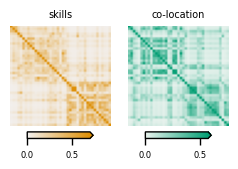

In [25]:
fig, axes = plt.subplots(1,2,figsize=(6*cm, 4*cm), layout='constrained')

for zname, ax in zip(['S', 'L'], axes):
    im = ax.imshow(dict_Z[zname], vmin=0, vmax=np.tril(dict_Z[zname], -1).max(), cmap=sns.light_palette(dict_color[zname], as_cmap=True))
    plt.colorbar(im, ax=ax, shrink=0.6, orientation='horizontal', aspect=10, extend='max')
    ax.set_axis_off()
    ax.set_title(dict_labels[zname])

In [26]:
pearsonr(dict_Z['S'][np.triu_indices_from(dict_Z['S'], 1)], dict_Z['L'][np.triu_indices_from(dict_Z['S'], 1)])

PearsonRResult(statistic=0.4586390050630953, pvalue=6.804880159993416e-44)

## Checking concavity

In [27]:
df_vectors.apply(lambda x: is_CND(get_hessian(dict_Z['S'], alpha=3, p=x.to_numpy())), axis=1).all()

True

In [28]:
df_vectors.apply(lambda x: is_CND(get_hessian(dict_Z['L'], alpha=3, p=x.to_numpy())), axis=1).all()

True

## Entropy

### Fix $\alpha=2$, vary Z

In [39]:
for zname in dict_Z:
    gdf[f'entropy_{zname}_2'] = df_vectors.apply(lambda x: get_entropy(dict_Z[zname], 2, x.to_numpy()), axis=1)

Text(0.5, 0.98, 'diversity, $\\alpha=2$')

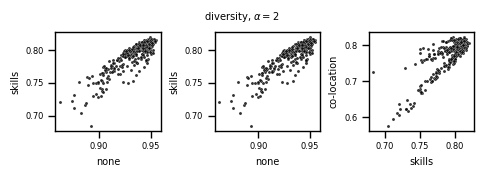

In [40]:
fig, axes = plt.subplots(1,3,figsize=(12*cm, 4.2*cm), layout='constrained')

for idx,(z1,z2) in enumerate([('I', 'S'), ('I', 'S'), ('S', 'L')]):
    ax = axes[idx]
    sns.scatterplot(
        gdf, 
        x = f"entropy_{z1}_2", 
        y = f"entropy_{z2}_2",
        ax = ax,
        color = 'black', alpha=.8, s=5
    )
    ax.set_xlabel(dict_labels[z1])
    ax.set_ylabel(dict_labels[z2])

fig.suptitle("diversity, " + r'$\alpha=2$')

Text(0.5, 0.98, 'ranks by diversity, $\\alpha=2$')

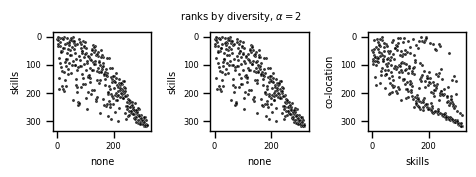

In [41]:
temp = gdf[[f'entropy_{zname}_2' for zname in dict_Z]].rank(ascending=False)

fig, axes = plt.subplots(1,3,figsize=(12*cm, 4.2*cm), layout='constrained', sharex=True)

for idx,(z1,z2) in enumerate([('I', 'S'), ('I', 'S'), ('S', 'L')]):
    ax = axes[idx]
    sns.scatterplot(
        temp, 
        x = f"entropy_{z1}_2", 
        y = f"entropy_{z2}_2",
        ax = ax,
        color = 'black', alpha=.8, s=5
    )
    ax.set_xlabel(dict_labels[z1])
    ax.set_ylabel(dict_labels[z2])
    ax.set_aspect('equal')
    ax.invert_yaxis()
fig.suptitle("ranks by diversity, " + r'$\alpha=2$')

### Fix skills similarity, vary $\alpha$

In [42]:
for alpha in list_alpha:
    gdf[f'entropy_S_{alpha}'] = df_vectors.apply(lambda x: get_entropy(dict_Z['S'], alpha, x.to_numpy()), axis=1)

In [43]:
gdf[[f'entropy_S_{alpha}' for alpha in list_alpha]].corr('kendall').round(2)

,entropy_S_1.0,entropy_S_2.0,entropy_S_3.0
entropy_S_1.0,1.00,0.94,0.90
entropy_S_2.0,0.94,1.00,0.96
entropy_S_3.0,0.90,0.96,1.00


Text(0.5, 0.98, 'diversity, skills similarity')

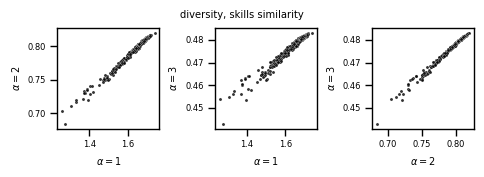

In [44]:
fig, axes = plt.subplots(1,3,figsize=(12*cm, 4.2*cm), layout='constrained')

for idx,(a1,a2) in enumerate([(1.0,2.0), (1.0,3.0), (2.0,3.0)]):
    ax = axes[idx]
    sns.scatterplot(
        gdf, 
        x = f"entropy_S_{a1}", 
        y = f"entropy_S_{a2}",
        ax = ax,
        color = 'black', alpha=.8, s=5
    )
    ax.set_xlabel(r"$\alpha=$"+str(int(a1)))
    ax.set_ylabel(r"$\alpha=$"+str(int(a2)))

fig.suptitle("diversity, skills similarity")

Text(0.5, 0.98, 'ranks by diversity, skills similarity')

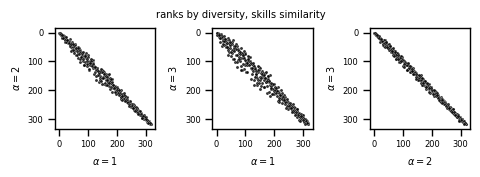

In [45]:
temp = gdf[[f'entropy_S_{alpha}' for alpha in list_alpha]].rank(ascending=False)

fig, axes = plt.subplots(1,3,figsize=(12*cm, 4.2*cm), layout='constrained')

for idx,(a1,a2) in enumerate([(1.0,2.0), (1.0,3.0), (2.0,3.0)]):
    ax = axes[idx]
    sns.scatterplot(
        temp, 
        x = f"entropy_S_{a1}", 
        y = f"entropy_S_{a2}",
        ax = ax,
        color = 'black', alpha=.8, s=5
    )
    ax.set_xlabel(r"$\alpha=$"+str(int(a1)))
    ax.set_ylabel(r"$\alpha=$"+str(int(a2)))
    ax.set_aspect('equal')
    ax.invert_yaxis()

fig.suptitle("ranks by diversity, skills similarity")

Check if $\alpha=10$ makes a difference

In [46]:
gdf[f'entropy_S_{10.0}'] = df_vectors.apply(lambda x: get_entropy(dict_Z['S'], 10.0, x.to_numpy()), axis=1)
gdf[['entropy_S_2.0', 'entropy_S_10.0']].corr('kendall')

,entropy_S_2.0,entropy_S_10.0
entropy_S_2.0,1.000000,0.827431
entropy_S_10.0,0.827431,1.000000


Text(0.5, 0.98, 'diversity, skills similarity')

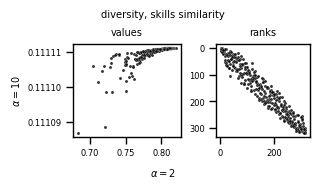

In [47]:
fig, axes = plt.subplots(1,2, figsize=(8*cm, 4.5*cm), layout='constrained',)

ax = axes[0]
sns.scatterplot(
    gdf, 
    x = f"entropy_S_{2.0}", 
    y = f"entropy_S_{10.0}",
    ax = ax,
    color = 'black', alpha=.8, s=5
)
ax.set_xlabel('')
ax.set_ylabel(r"$\alpha=10$")
ax.set_title('values')

ax = axes[1]
sns.scatterplot(
    gdf[['entropy_S_2.0', 'entropy_S_10.0']].rank(ascending=False), 
    x = f"entropy_S_{2.0}", 
    y = f"entropy_S_{10.0}",
    ax = ax,
    color = 'black', alpha=.8, s=5
)
ax.set_aspect('equal')
ax.invert_yaxis()
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('ranks')

fig.supxlabel(r"$\alpha=2$")
fig.suptitle('diversity, skills similarity')

## Divergence

### Fix $\alpha=2$, vary Z

In [48]:
for zname, Z in dict_Z.items():
    gdf[f'div_{zname}_2'] = df_vectors.apply(lambda x: get_divergence(Z, 2, x.to_numpy(), df_occs['population'].to_numpy()), axis=1)
gdf[[f'div_{zname}_2' for zname in dict_Z]].corr('kendall').round(2)

,div_I_2,div_S_2,div_L_2
div_I_2,1.00,0.79,0.8
div_S_2,0.79,1.00,0.9
div_L_2,0.80,0.90,1.0


Text(0.5, 0.98, 'atypicality, $\\alpha=2$')

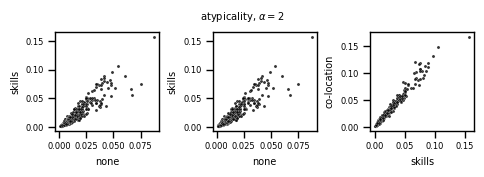

In [49]:
fig, axes = plt.subplots(1,3,figsize=(12*cm, 4.2*cm), layout='constrained')

for idx,(z1,z2) in enumerate([('I', 'S'), ('I', 'S'), ('S', 'L')]):
    ax = axes[idx]
    sns.scatterplot(
        gdf, 
        x = f"div_{z1}_2", 
        y = f"div_{z2}_2",
        ax = ax,
        color = 'black', alpha=.8, s=5
    )
    ax.set_xlabel(dict_labels[z1])
    ax.set_ylabel(dict_labels[z2])

fig.suptitle("atypicality, " + r'$\alpha=2$')

Text(0.5, 0.98, 'ranks by atypicality, $\\alpha=2$')

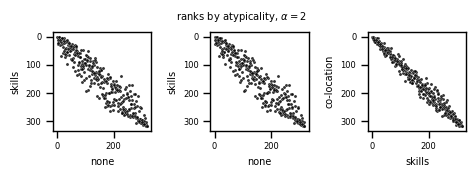

In [50]:
temp = gdf[[f'div_{zname}_2' for zname in dict_Z]].rank(ascending=False)

fig, axes = plt.subplots(1,3,figsize=(12*cm, 4.2*cm), layout='constrained', sharex=True)

for idx,(z1,z2) in enumerate([('I', 'S'), ('I', 'S'), ('S', 'L')]):
    ax = axes[idx]
    sns.scatterplot(
        temp, 
        x = f"div_{z1}_2", 
        y = f"div_{z2}_2",
        ax = ax,
        color = 'black', alpha=.8, s=5
    )
    ax.set_xlabel(dict_labels[z1])
    ax.set_ylabel(dict_labels[z2])
    ax.set_aspect('equal')
    ax.invert_yaxis()
fig.suptitle("ranks by atypicality, " + r'$\alpha=2$')

### Fix skills similarity, vary $\alpha$

In [52]:
for a in list_alpha:
    gdf[f'div_S_{a}'] = df_vectors.apply(lambda x: get_divergence(dict_Z['S'], a, x.to_numpy(), df_occs['population'].to_numpy()), axis=1)

gdf[[f'div_S_{a}' for a in list_alpha]].corr('kendall').round(2)

,div_S_1.0,div_S_2.0,div_S_3.0
div_S_1.0,1.00,0.94,0.89
div_S_2.0,0.94,1.00,0.95
div_S_3.0,0.89,0.95,1.00


Text(0.5, 0.98, 'atypicality, skills similarity')

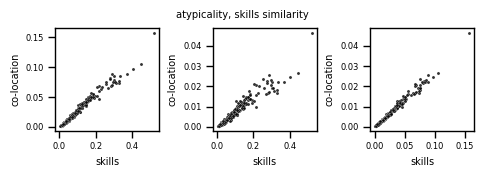

In [53]:
fig, axes = plt.subplots(1,3,figsize=(12*cm, 4.2*cm), layout='constrained')

for idx,(a1,a2) in enumerate([(1.0, 2.0), (1.0, 3.0), (2.0, 3.0)]):
    ax = axes[idx]
    sns.scatterplot(
        gdf, 
        x = f"div_S_{a1}", 
        y = f"div_S_{a2}",
        ax = ax,
        color = 'black', alpha=.8, s=5
    )
    ax.set_xlabel(dict_labels[z1])
    ax.set_ylabel(dict_labels[z2])

fig.suptitle("atypicality, skills similarity")

Text(0.5, 0.98, 'ranks by atypicality, skills similarity')

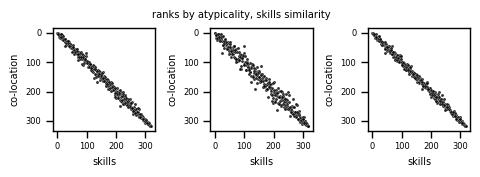

In [54]:
temp = gdf[[f'div_S_{a}' for a in list_alpha]].rank(ascending=False)

fig, axes = plt.subplots(1,3,figsize=(12*cm, 4.2*cm), layout='constrained')

for idx,(a1,a2) in enumerate([(1.0, 2.0), (1.0, 3.0), (2.0, 3.0)]):
    ax = axes[idx]
    sns.scatterplot(
        temp, 
        x = f"div_S_{a1}", 
        y = f"div_S_{a2}",
        ax = ax,
        color = 'black', alpha=.8, s=5
    )
    ax.set_xlabel(dict_labels[z1])
    ax.set_ylabel(dict_labels[z2])
    ax.set_aspect('equal')
    ax.invert_yaxis()

fig.suptitle("ranks by atypicality, skills similarity")

## Clustering

In [4]:
dict_c = {
    zname : Clustering.from_vectors(
        vectors=df_vectors.to_numpy(),
        weights=gdf['population'].to_numpy()
    )
    for zname in dict_Z
}

dict_results = {
    zname : dict()
    for zname in dict_Z
}

for zname, zresults in dict_results.items():
    for k in range(2,7):
        zresults[k] = dict_c[zname].fit(k, dict_Z[zname], 2, n_trials=100, verbose=False, random_seed=42, rel_tol=1e-12, max_iter=500)

In [56]:
from sklearn.metrics import adjusted_mutual_info_score as AMI

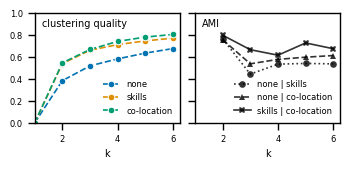

In [66]:
dict_pairs_plotstyle = {
    ('I', 'S') : dict(color='black', ls=':', marker='o'),
    ('I', 'L') : dict(color='black', ls='--', marker='^'),
    ('S', 'L') : dict(color='black', ls='-', marker='X')
}


fig, axes = plt.subplots(1,2,figsize=(8.6*cm,4*cm), layout='constrained', sharex=True, sharey=True)

for zname in dict_Z:
    sns.lineplot(
        x = range(1,7),
        y = [0] + [i[2]/dict_c[zname].total_information for i in dict_results[zname].values()],
        label = f"{dict_labels[zname]}",
        ax = axes[0],
        ls = '--', marker='o', color=dict_color[zname],
    )
axes[0].text(0.05, 0.95, 'clustering quality', transform=axes[0].transAxes, va='top', ha='left', fontsize=7,)

for (z1,z2) in dict_pairs_plotstyle:
    sns.lineplot(
        x = range(2,7),
        y = [AMI(dict_results[z1][k][1], dict_results[z2][k][1]) for k in range(2,7)],
        label = f"{dict_labels[z1]} | {dict_labels[z2]}",
        ax = axes[1], alpha=.8, markeredgewidth=0.0,
        **dict_pairs_plotstyle[(z1,z2)]
    )
axes[1].text(0.05, 0.95, 'AMI', transform=axes[1].transAxes, va='top', ha='left', fontsize=7,)

for ax in axes:
    ax.legend(frameon=False, loc='lower right')
    ax.set_xlabel('k')
    ax.set_ylim(0, 1)
    ax.set_xlim(1,None)

In [5]:
# The cluster IDs can be accessed as follows:

dict_results['I'][2][1] # For the cluster ids of the 2-way partition with Z=I

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

### Load clustering results from the paper

In [73]:
gdf['none_2'] = pd.read_csv('outputs/ew_occupations/df_clustering_results_none.csv', index_col=0)['none_2']
gdf['skills_2'] = pd.read_csv('outputs/ew_occupations/df_clustering_results_skills.csv', index_col=0)['skills_2']
gdf['co-location_2'] = pd.read_csv('outputs/ew_occupations/df_clustering_results_colocation.csv', index_col=0)['co-location_2']

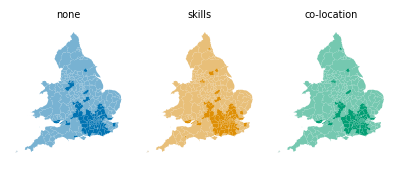

In [74]:
fig, axes = plt.subplots(1,3, figsize=(10*cm, 4*cm), layout='constrained')

for ax, zname in zip(axes, dict_Z.keys()):
    for i in [0,1]:
        gdf[gdf[f"{dict_labels[zname]}_2"] == i].plot(
            ax = ax,
            color = dict_3colorpalette[zname][i]
        )
    ax.set_title(dict_labels[zname])
    ax.set_axis_off()

## Replicating Fig. 3

In [75]:
gdf['none_3'] = pd.read_csv('outputs/ew_occupations/df_clustering_results_none.csv', index_col=0)['none_3']
gdf['skills_3'] = pd.read_csv('outputs/ew_occupations/df_clustering_results_skills.csv', index_col=0)['skills_3']
gdf['co-location_3'] = pd.read_csv('outputs/ew_occupations/df_clustering_results_colocation.csv', index_col=0)['co-location_3']

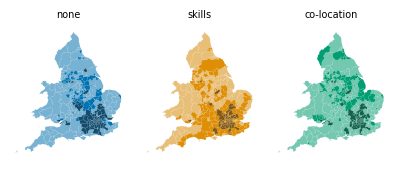

In [81]:
fig, axes = plt.subplots(1,3, figsize=(10*cm, 4*cm), layout='constrained')

dict_manual_colormap = {k: {0:0, 1:1, 2:2} for k in dict_Z.keys()}
dict_manual_colormap['I']= {0:0, 1:2, 2:1}

for ax, zname in zip(axes, dict_Z.keys()):
    for i in [0,1,2]:
        gdf[gdf[f"{dict_labels[zname]}_3"] == i].plot(
            ax = ax,
            color = dict_3colorpalette[zname][dict_manual_colormap[zname][i]]
        )
    ax.set_title(dict_labels[zname])
    ax.set_axis_off()

### RCAs of regions

In [25]:
import itertools

Skills similarity

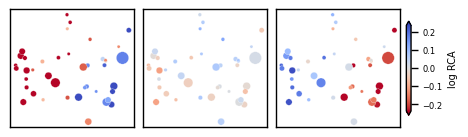

In [86]:
r = Result(df_vectors.to_numpy(), dict_c['S'].weights, dict_Z['S'], 2, dict_results['S'][3][0], dict_results['S'][3][1])

fig, axes = plt.subplots(1,3,figsize=((3.2*3+2)*cm, 3.2*cm), layout='constrained') 
halfrange = np.quantile(np.abs(np.log10(r.centers/ df_occs['population'].to_numpy())), .8)

for i, ax in enumerate(axes[::-1]):
    sns.scatterplot(
        df_occs,
        x= 'x_S', y='y_S',
        hue= np.log10(r.centers[i] / df_occs['population'].to_numpy()),
        hue_norm = mpl.colors.CenteredNorm(vcenter=0., halfrange=halfrange),
        palette = 'coolwarm_r',
        size='population', sizes=(5,80),
        legend=False,
        ax= ax,
    )
    ax.set_axis_on()
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.set_xticks([]); ax.set_yticks([])

sm = mpl.cm.ScalarMappable(cmap=sns.color_palette('coolwarm_r',as_cmap=True), norm=mpl.colors.CenteredNorm(vcenter=0., halfrange=halfrange),)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axes[-1], extend='both', shrink=0.8)
cbar.set_label("log RCA")

Co-location similarity

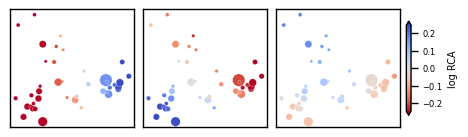

In [87]:
r = Result(df_vectors.to_numpy(), dict_c['L'].weights, dict_Z['L'], 2, dict_results['L'][3][0], dict_results['L'][3][1])

fig, axes = plt.subplots(1,3,figsize=((3.2*3+2)*cm, 3.2*cm), layout='constrained') 
halfrange = np.quantile(np.abs(np.log10(r.centers/ df_occs['population'].to_numpy())), .8)

for i, ax in enumerate(axes[::-1]):
    sns.scatterplot(
        df_occs,
        x= 'x_L', y='y_L',
        hue= np.log10(r.centers[i] / df_occs['population'].to_numpy()),
        hue_norm = mpl.colors.CenteredNorm(vcenter=0., halfrange=halfrange),
        palette = 'coolwarm_r',
        size='population', sizes=(5,80),
        legend=False,
        ax= ax,
    )
    ax.set_axis_on()
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.set_xticks([]); ax.set_yticks([])
sm = mpl.cm.ScalarMappable(cmap=sns.color_palette('coolwarm_r',as_cmap=True), norm=mpl.colors.CenteredNorm(vcenter=0., halfrange=halfrange),)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axes[-1], extend='both', shrink=0.8)
cbar.set_label("log RCA")

## Describing the clusters, replicating Table 1

In [15]:
ri = Result(df_vectors.to_numpy(), dict_c['I'].weights, dict_Z['I'], 2, dict_results['I'][3][0], dict_results['I'][3][1])
ri.describe()

Results of clustering
-----------------
318 distributions of length 41 into 3 clusters.
Fraction of information explained: 0.521
-------------
Cluster 0:
154 points with 0.423 weight.
Within-cluster information=0.19, Between-cluster contribution=0.06
-------------
Cluster 1:
90 points with 0.336 weight.
Within-cluster information=0.177, Between-cluster contribution=0.254
-------------
Cluster 2:
74 points with 0.24 weight.
Within-cluster information=0.113, Between-cluster contribution=0.208


In [21]:
rs = Result(df_vectors.to_numpy(), dict_c['S'].weights, dict_Z['S'], 2, dict_results['S'][3][0], dict_results['S'][3][1])
rs.describe()

Results of clustering
-----------------
318 distributions of length 41 into 3 clusters.
Fraction of information explained: 0.663
-------------
Cluster 0:
130 points with 0.38 weight.
Within-cluster information=0.145, Between-cluster contribution=0.287
-------------
Cluster 1:
127 points with 0.374 weight.
Within-cluster information=0.103, Between-cluster contribution=0.008
-------------
Cluster 2:
61 points with 0.246 weight.
Within-cluster information=0.089, Between-cluster contribution=0.369


In [81]:
rs.information_explained, 1 - rs.information_explained

(0.6631968071801544, 0.3368031928198456)

In [70]:
print(
    np.array([ rs.arr_cluster_weights.round(2)*100, (rs.arr_between_cluster_information / rs.arr_cluster_weights).round(2), rs.arr_between_cluster_information.round(3)*100, (rs.arr_within_cluster_information / rs.arr_cluster_weights).round(2), rs.arr_within_cluster_information.round(3)*100 ]).T
)


[[3.80e+01 7.50e-01 2.87e+01 3.80e-01 1.45e+01]
 [3.70e+01 2.00e-02 8.00e-01 2.80e-01 1.03e+01]
 [2.50e+01 1.50e+00 3.69e+01 3.60e-01 8.90e+00]]


In [76]:
rl = Result(df_vectors.to_numpy(), dict_c['L'].weights, dict_Z['L'], 2, dict_results['L'][3][0], dict_results['L'][3][1])
rl.describe()

Results of clustering
-----------------
318 distributions of length 41 into 3 clusters.
Fraction of information explained: 0.67
-------------
Cluster 0:
154 points with 0.432 weight.
Within-cluster information=0.138, Between-cluster contribution=0.026
-------------
Cluster 1:
96 points with 0.292 weight.
Within-cluster information=0.089, Between-cluster contribution=0.265
-------------
Cluster 2:
68 points with 0.277 weight.
Within-cluster information=0.103, Between-cluster contribution=0.379


In [82]:
rl.information_explained, 1 - rl.information_explained

(0.6703096063378646, 0.3296903936621354)

In [78]:
print(
    np.array([ rl.arr_cluster_weights.round(3)*100, (rl.arr_between_cluster_information / rl.arr_cluster_weights).round(2), rl.arr_between_cluster_information.round(3)*100, (rl.arr_within_cluster_information / rl.arr_cluster_weights).round(2), rl.arr_within_cluster_information.round(3)*100 ]).T
)


[[43.2   0.06  2.6   0.32 13.8 ]
 [29.2   0.91 26.5   0.3   8.9 ]
 [27.7   1.37 37.9   0.37 10.3 ]]
